In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [140]:
df = pd.read_csv("/content/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [141]:
print(f"Netflix data having {df.shape[0]} rows and {df.shape[1]} columns")

Netflix data having 8807 rows and 12 columns


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


As you see columns like director, cast, country, date_added, rating, duration having null values..we will try to impute them or remove if unnecessary.

In [143]:
df.drop("release_year",axis=1).describe()

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


## Changing columns to correct datatype

Changing to datetime datatype

In [144]:

df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="%B %d, %Y").astype("datetime64[ns]")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [145]:
df["date_added"].dt.month_name()

,date_added
0,September
1,September
2,September
3,September
4,September
...,...
8802,November
8803,July
8804,November
8805,January


In [146]:
df["day_added_name"] = df["date_added"].dt.day_name()
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,2021.0,September
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",Monday,2019.0,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


In [147]:
df = df.drop(columns="date_added")
df


,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,2021.0,September
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",Monday,2019.0,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


In [148]:
df.rating.value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


Convert categorical columns

In [149]:
df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')

In [150]:
df.shape

(8807, 14)

## Missing value Detection and treatment

Identify missing values

In [151]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 show_id              0
type                 0
title                0
director          2634
cast               825
country            831
release_year         0
rating               4
duration             3
listed_in            0
description          0
day_added_name      10
year_added          10
month_added         10
dtype: int64


In [152]:
df.groupby("director")["country"].agg("count").sort_values(ascending=False)

,country
director,
"Raúl Campos, Jan Suter",18
Marcus Raboy,15
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
...,...
Peter Thorwarth,0
Funke Akindele,0
Nibal Arakji,0


In [153]:
for i in df.columns:
  print(i,"--->>",df[df['director'].isnull()][i].nunique())

show_id --->> 2634
type --->> 2
title --->> 2634
director --->> 0
cast --->> 2220
country --->> 188
release_year --->> 47
rating --->> 12
duration --->> 102
listed_in --->> 272
description --->> 2628
day_added_name --->> 7
year_added --->> 10
month_added --->> 12


In [154]:
total_per_null_dir = np.round((df['director'].isnull().sum()/df.shape[0])*100,2)
print(f"{total_per_null_dir} % directors entries are null")

29.91 % directors entries are null


30% of entries are null actually its better drop director column but for annalysis
we impute nan director with NO director"

In [155]:
df['director'] = df['director'].fillna("no director")
df

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,no director,NaN,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,2021.0,September
4,s5,TV Show,Kota Factory,no director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8803,s8804,TV Show,Zombie Dumb,no director,NaN,NaN,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",Monday,2019.0,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


In [156]:
for i in df.columns:
  print(i,"--->>",df[df['cast'].isnull()][i].nunique())


show_id --->> 825
type --->> 2
title --->> 825
director --->> 434
cast --->> 0
country --->> 123
release_year --->> 32
rating --->> 12
duration --->> 114
listed_in --->> 94
description --->> 822
day_added_name --->> 7
year_added --->> 9
month_added --->> 12


For name sake we are imputing cast column with "No cast"

In [157]:
df['cast'] = df['cast'].fillna("No cast")
df

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,no director,No cast,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,2021.0,September
4,s5,TV Show,Kota Factory,no director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8803,s8804,TV Show,Zombie Dumb,no director,No cast,NaN,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",Monday,2019.0,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


For nan in country we fill with no country for analysis purpose

In [158]:
df['country'] = df['country'].fillna("No country")
df

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,no director,No cast,No country,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,2021.0,September
4,s5,TV Show,Kota Factory,no director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8803,s8804,TV Show,Zombie Dumb,no director,No cast,No country,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",Monday,2019.0,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


As you see there are 4 nan in rating and 3 entries which is of not rating type ('74 min','84 min','66 min')

In [159]:
print("No of null in ratings:",df['rating'].isnull().sum())
list(df['rating'].unique())

No of null in ratings: 4


['PG-13',
 'TV-MA',
 'PG',
 'TV-14',
 'TV-PG',
 'TV-Y',
 'TV-Y7',
 'R',
 'TV-G',
 'G',
 'NC-17',
 '74 min',
 '84 min',
 '66 min',
 'NR',
 nan,
 'TV-Y7-FV',
 'UR']

Here we are going to impute the above mins label rating and nan in rating with "NR - not rating yet"

In [160]:
df['rating'] = df['rating'].apply(lambda x: "NR" if pd.isna(x) or (isinstance(x, str) and "min" in x) else x)
df['rating'] = df['rating'].apply(lambda x: "NR" if pd.isna(x) or (isinstance(x, str) and "min" in x) else x)
df

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,no director,No cast,No country,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,2021.0,September
4,s5,TV Show,Kota Factory,no director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8803,s8804,TV Show,Zombie Dumb,no director,No cast,No country,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",Monday,2019.0,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


In [161]:
df['duration'].value_counts()

,count
duration,
1 Season,1793
2 Seasons,425
3 Seasons,199
90 min,152
94 min,146
...,...
16 min,1
186 min,1
193 min,1


Removing these 3 rows and 10 rows of date added column

In [162]:
df[df['duration'].isnull()]

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017,NR,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",Tuesday,2017.0,April
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2010,NR,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,Friday,2016.0,September
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2015,NR,NaN,Movies,The comic puts his trademark hilarious/thought...,Monday,2016.0,August


In [163]:
df = df.dropna(subset=['duration', 'day_added_name'])
df

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,no director,No cast,No country,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,2021.0,September
4,s5,TV Show,Kota Factory,no director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8803,s8804,TV Show,Zombie Dumb,no director,No cast,No country,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",Monday,2019.0,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


In [164]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
release_year,0
rating,0
duration,0
listed_in,0


As you see above all missing value columns treated

## Visual Analysis

Text(0.5, 1.0, 'Count of Type of shows in posted in Netflix')

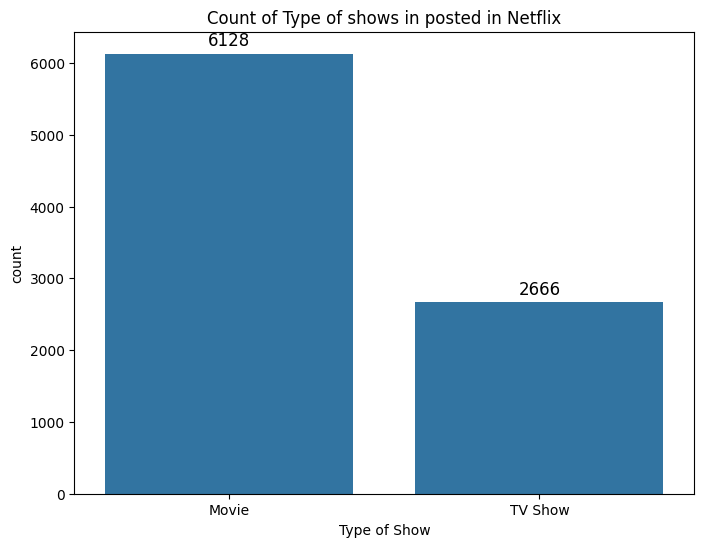

In [165]:
plt.figure(figsize=(8,6))
ax = sns.barplot(df['type'].value_counts())
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=12, padding=3)
plt.xlabel("Type of Show")
plt.title("Count of Type of shows in posted in Netflix")

As you see In total shows posted in Netflix there are 6128 Movies and 2666 Tv show

In [166]:
df['country']

,country
0,United States
1,South Africa
2,No country
3,No country
4,India
...,...
8802,United States
8803,No country
8804,United States
8805,United States


In [167]:
df_exploded = df.assign(country=df['country'].str.split(', ')).explode('country')
country_counts = df_exploded.groupby('country')['type'].count().sort_values(ascending=False).head(10)
print(country_counts)


country
United States     3680
India             1046
No country         830
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: type, dtype: int64


In [168]:
top_country_by_type = list(country_counts.index)
df_top10_coun = df[df['country'].isin(top_country_by_type)]
df_top10_coun

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,no director,No cast,No country,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,2021.0,September
4,s5,TV Show,Kota Factory,no director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,2021.0,September
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",No country,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8803,s8804,TV Show,Zombie Dumb,no director,No cast,No country,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",Monday,2019.0,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


Text(0.5, 1.0, 'Distribution of Shows of Top 10 countries by Type')

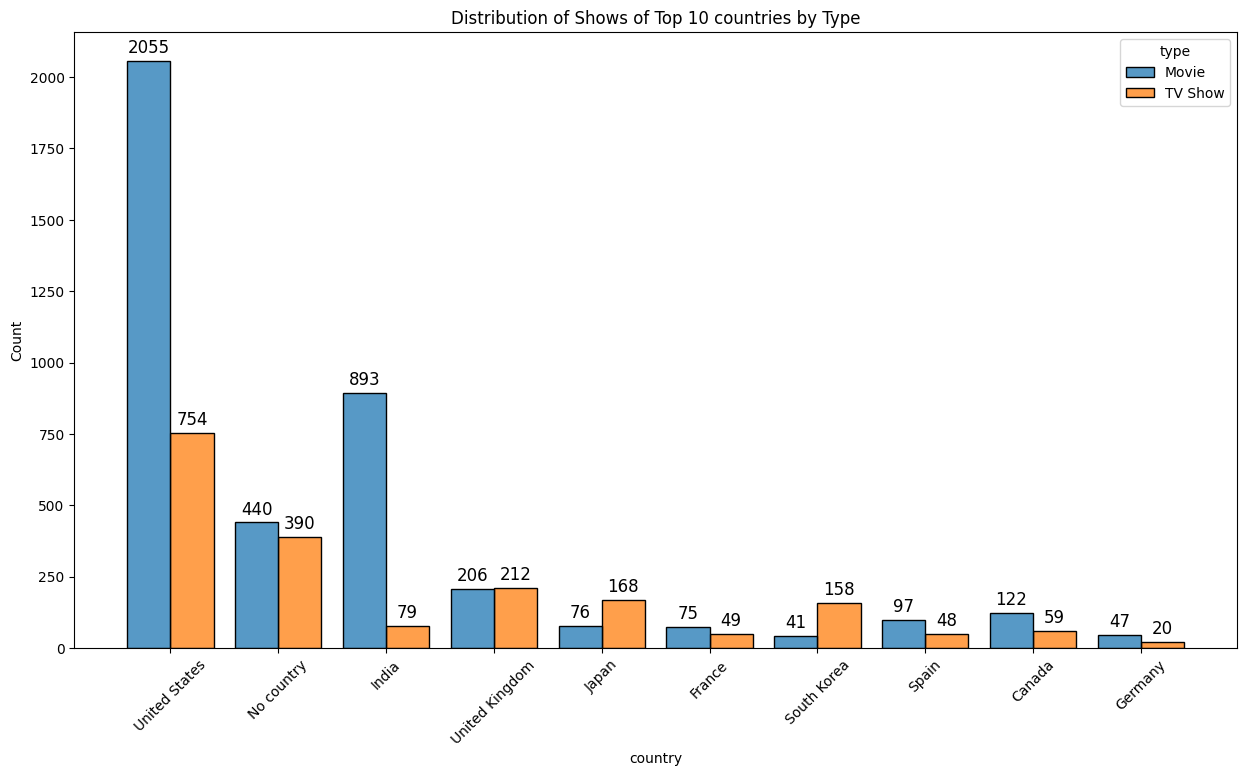

In [169]:
plt.figure(figsize=(15,8))
ax = sns.histplot(data=df_top10_coun,x="country",hue="type",  multiple="dodge", shrink=0.8)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=12, padding=3)
plt.xticks(rotation=45)
plt.title("Distribution of Shows of Top 10 countries by Type")

As you see Above USA is producing more number of Shows in which 2055 are Movies and 754 are Tv shows

In [170]:
df_movies = df[df['type']=="Movie"]
df_movies

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",No country,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Friday,2021.0,September
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Friday,2021.0,September
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,Friday,2021.0,September
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,Thursday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,Wednesday,2016.0,March
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


In [171]:
df_movies['duration'] = [i.replace("min","").strip() for i in df_movies['duration']]
df_movies['duration'] = df_movies['duration'].astype("int64")
df_movies

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",No country,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Friday,2021.0,September
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Friday,2021.0,September
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021,PG-13,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...,Friday,2021.0,September
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021,TV-MA,127,"Dramas, International Movies",After most of her family is murdered in a terr...,Thursday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2015,TV-MA,96,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,Wednesday,2016.0,March
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",Wednesday,2019.0,November
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,Friday,2019.0,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Saturday,2020.0,January


In [172]:
df_movies['rating'].value_counts()

,count
rating,
TV-MA,2062
TV-14,1427
R,797
TV-PG,540
PG-13,490
PG,287
TV-Y7,139
TV-Y,131
TV-G,126


Text(0.5, 1.0, 'Distribution of Movie Duration for each Rating')

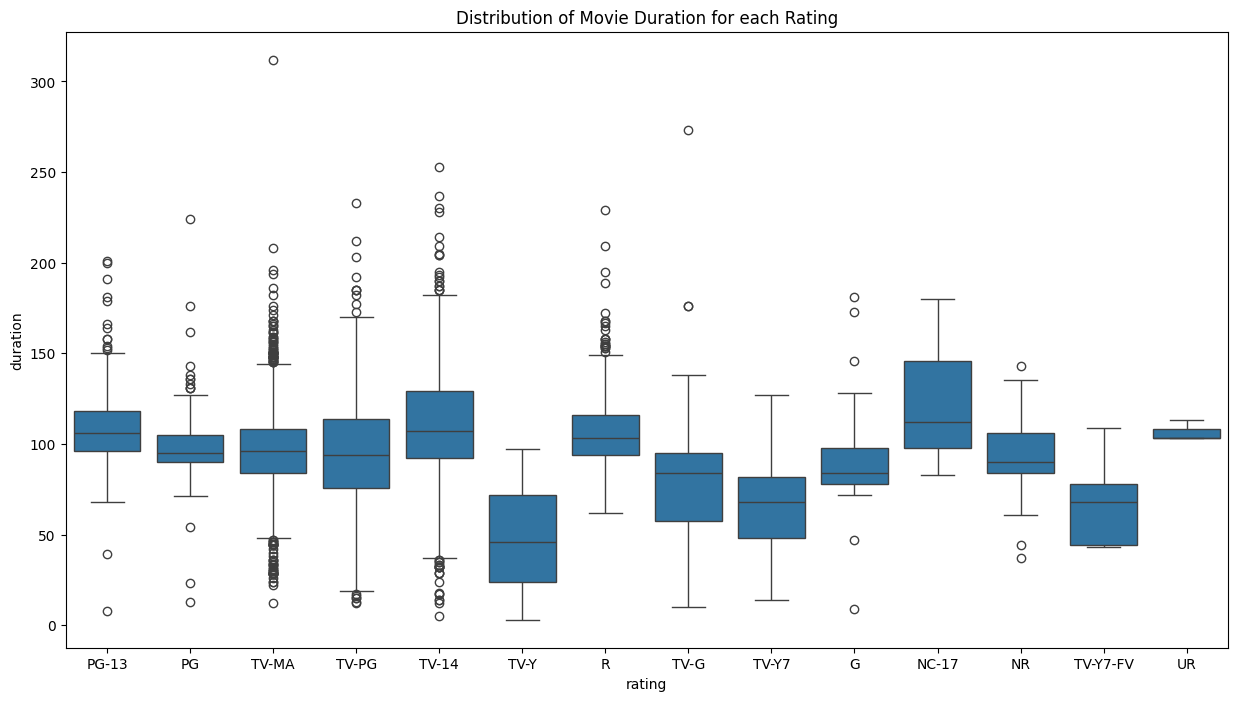

In [173]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df_movies,x="rating", y="duration")
plt.title("Distribution of Movie Duration for each Rating")

The plot shows how Netflix movie durations vary across different ratings, with more mature content (TV-MA, R) potentially featuring longer durations, while family-friendly content tends to be shorter. As you see TV-MA, TV-14 , R having more outliers

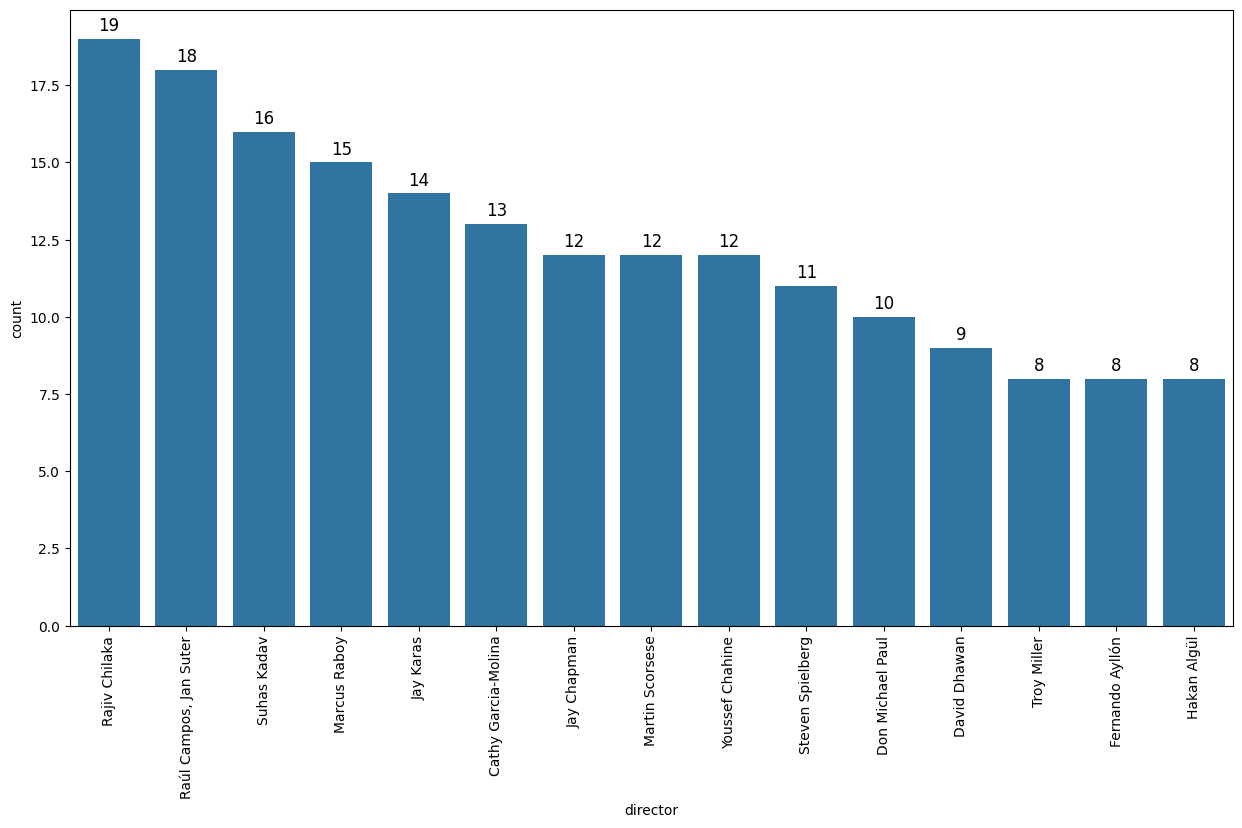

In [174]:
most_movie_director = df_movies[df_movies['director']!="no director"]['director'].value_counts().head(15)
plt.figure(figsize=(15,8))
ax = sns.barplot(most_movie_director)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=12, padding=3)
plt.xticks(rotation=90)
plt.show()

As you see "Rajiv Chilaka" directed more number of movies

In [175]:
df['listed_in']

,listed_in
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."
...,...
8802,"Cult Movies, Dramas, Thrillers"
8803,"Kids' TV, Korean TV Shows, TV Comedies"
8804,"Comedies, Horror Movies"
8805,"Children & Family Movies, Comedies"


In [176]:
df_listed_in_exploded = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')
df_listed_in_exploded

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,Children & Family Movies,"Dragged from civilian life, a former superhero...",Saturday,2020.0,January
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,Comedies,"Dragged from civilian life, a former superhero...",Saturday,2020.0,January
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2015,TV-14,111 min,Dramas,A scrappy but poor boy worms his way into a ty...,Saturday,2019.0,March
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2015,TV-14,111 min,International Movies,A scrappy but poor boy worms his way into a ty...,Saturday,2019.0,March


In [177]:
top_genres = df_listed_in_exploded['listed_in'].value_counts().head(20).index
top_genres_df = df_listed_in_exploded[df_listed_in_exploded['listed_in'].isin(top_genres)]
top_genres_df

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
1,s2,TV Show,Blood & Water,no director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,Friday,2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021,TV-MA,1 Season,International TV Shows,To protect his family from a powerful drug lor...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,Children & Family Movies,"Dragged from civilian life, a former superhero...",Saturday,2020.0,January
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,Comedies,"Dragged from civilian life, a former superhero...",Saturday,2020.0,January
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2015,TV-14,111 min,Dramas,A scrappy but poor boy worms his way into a ty...,Saturday,2019.0,March
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2015,TV-14,111 min,International Movies,A scrappy but poor boy worms his way into a ty...,Saturday,2019.0,March


<Axes: xlabel='listed_in', ylabel='type'>

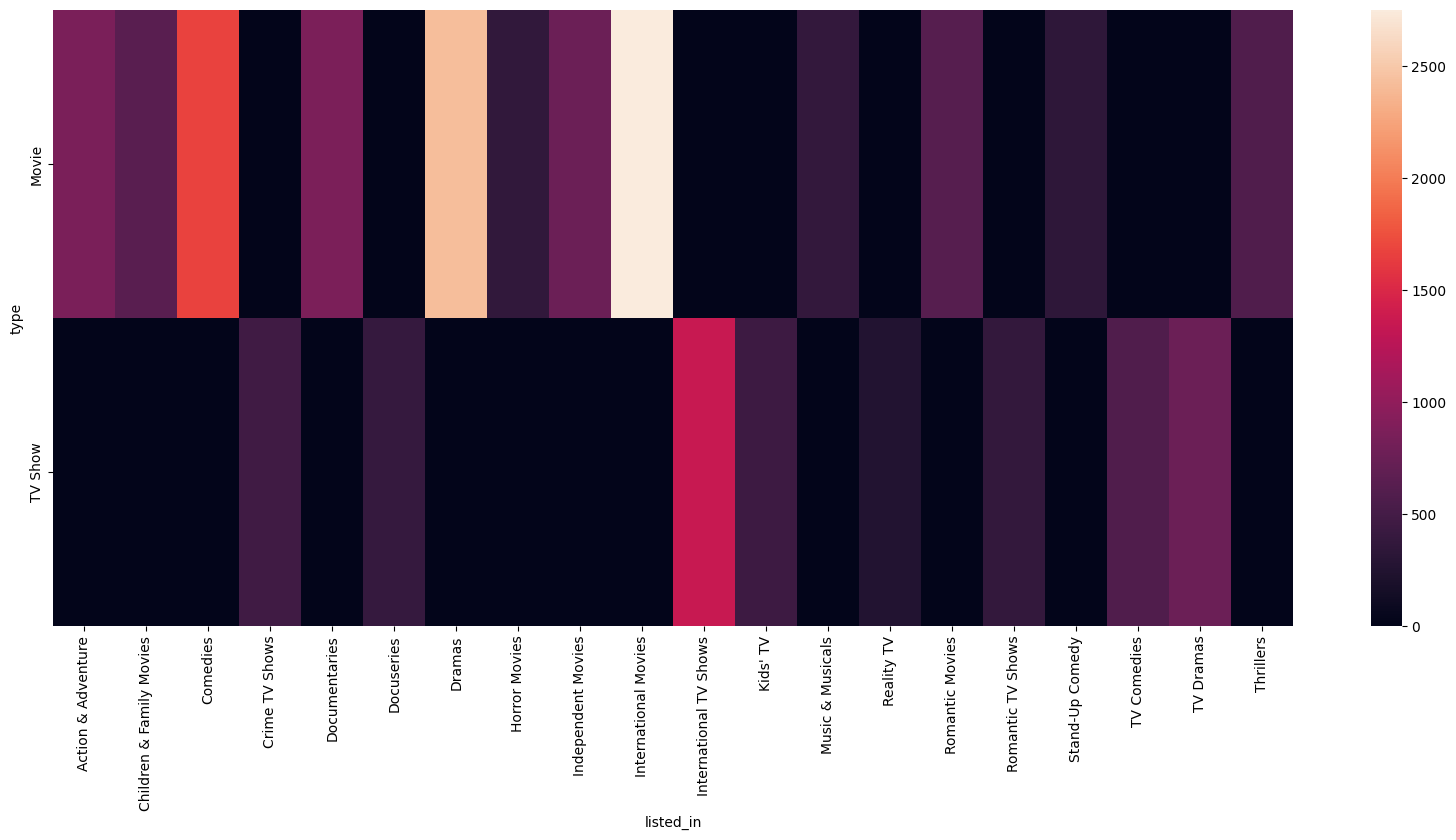

In [178]:
plt.figure(figsize= (20,8))
crosstab_genres = pd.crosstab(top_genres_df["type"],top_genres_df["listed_in"])
sns.heatmap(crosstab_genres)

As you see from above most Movies are in International movies genre and most Tv shows are in International Tv shows.

<Figure size 1500x800 with 0 Axes>

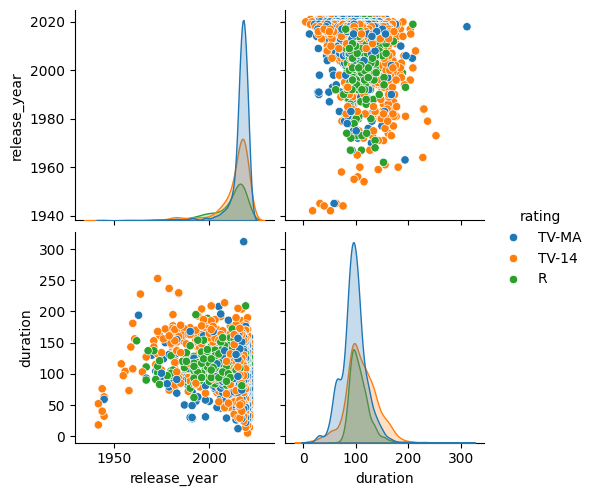

In [179]:
top3df__rating_movies = df_movies['rating'].value_counts().head(3).index
plt.figure(figsize=(15,8))
sns.pairplot(data=df_movies[df_movies['rating'].isin(top3df__rating_movies)], vars=["release_year","duration"], hue="rating")

TV-MA movies may have a wider range of durations, while TV-14 and R movies could be more clustered around typical movie lengths

In [180]:
df_without_Nocast = df_movies[df_movies['cast']!="No cast"]

In [181]:
df_movie_cast_exploded = df_without_Nocast.assign(cast=df_without_Nocast['cast'].str.split(', ')).explode('cast')
df_movie_cast_exploded

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day_added_name,year_added,month_added
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",Vanessa Hudgens,No country,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Friday,2021.0,September
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",Kimiko Glenn,No country,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Friday,2021.0,September
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",James Marsden,No country,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Friday,2021.0,September
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",Sofia Carson,No country,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Friday,2021.0,September
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",Liza Koshy,No country,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Friday,2021.0,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,s8807,Movie,Zubaan,Mozez Singh,Manish Chaudhary,India,2015,TV-14,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Saturday,2019.0,March
8806,s8807,Movie,Zubaan,Mozez Singh,Meghna Malik,India,2015,TV-14,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Saturday,2019.0,March
8806,s8807,Movie,Zubaan,Mozez Singh,Malkeet Rauni,India,2015,TV-14,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Saturday,2019.0,March
8806,s8807,Movie,Zubaan,Mozez Singh,Anita Shabdish,India,2015,TV-14,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Saturday,2019.0,March


Text(0.5, 1.0, 'Most movie acted actors')

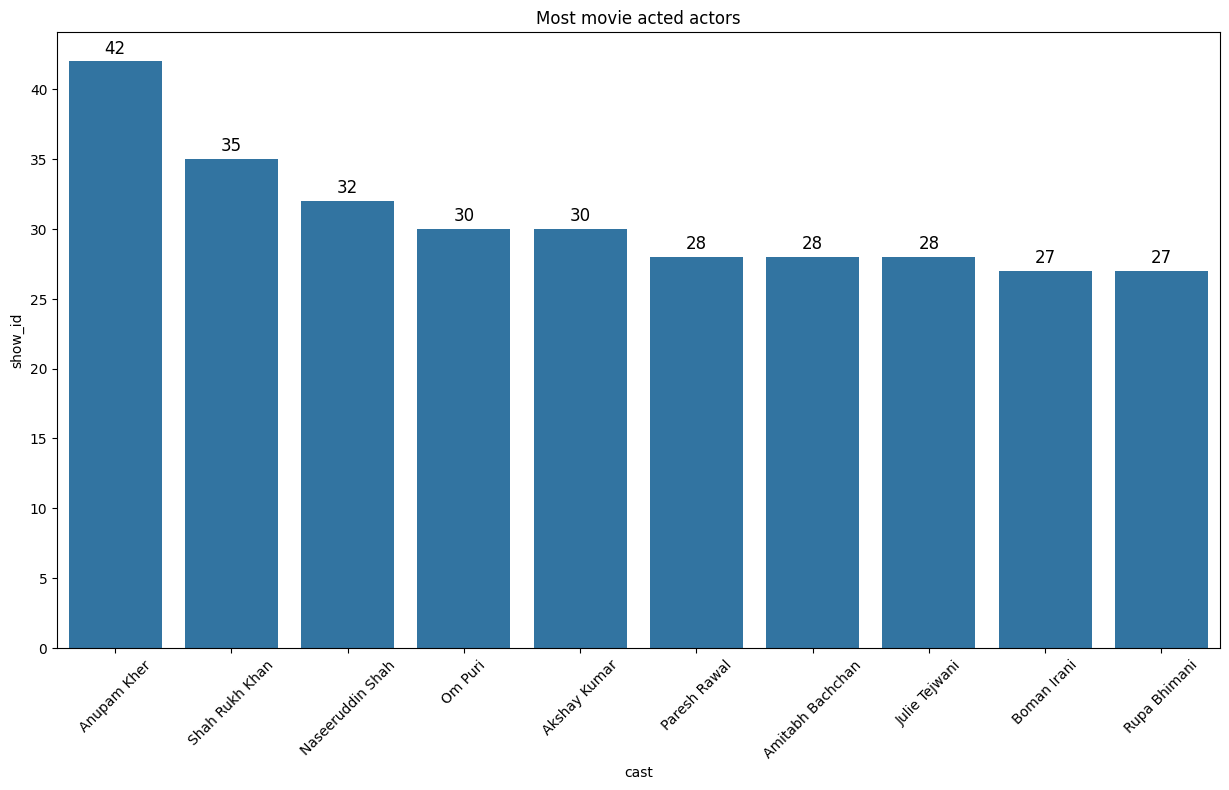

In [182]:
most_movie_acted_cast = df_movie_cast_exploded.groupby('cast')['show_id'].aggregate("count").sort_values(ascending=False).head(10)
plt.figure(figsize=(15,8))
ax = sns.barplot(most_movie_acted_cast)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=12, padding=3)
plt.xticks(rotation=45)
plt.title("Most movie acted actors")

As you see above "Anupam Kher" acted in more number of movies